In [ ]:
'''
This book joins a csv of players stats from the nfl combines in 1999-2023 to the players stats for all seasons.
The join is done through a weighted system of college, positio, name, and draft year

Then we get the EPA for QB, WR, TE, RB, and Def positions. Plus we get the average height,weight, team EPA for rosters 
'''

'\nThis book joins a csv of players stats from the nfl combines in 1999-2023 to the players stats for all seasons.\nThe join is done through a weighted system of college, positio, name, and draft year\n\nThen we get the EPA for QB, WR, TE, RB, and Def positions. Plus we get the average height,weight, team EPA for rosters \n'

In [ ]:
import pandas as pd
import numpy as np
import time
import re
from pathlib import Path
from tqdm import tqdm
from urllib.parse import quote_plus
import nflreadpy as nfl
import pandas as pd
from rapidfuzz import process,fuzz
from pprint import pprint
import matplotlib.pyplot as plt
from nameparser import HumanName
import os
import seaborn as sns

In [ ]:
# Paths

try:
    main_directory = Path(__file__).parent
except NameError:
    main_directory = Path(os.path.dirname(os.getcwd()))  # fallback for Jupyter

data_folder = main_directory / 'data' # data folder output
notebook_folder = main_directory / 'notebooks' 

In [ ]:
def clean(text):
    if pd.isna(text):
        return ""
    else:
        return (str(text).lower().strip())

def standard_name(text):
    np_name = HumanName(text)
    if len(np_name.middle) > 0:
        return f'{np_name.first} {np_name.middle} {np_name.last}'   
    return f'{np_name.first} {np_name.last}'



In [ ]:
def fuzz_college(text, comparison_set, threshold=80):
    if pd.isna(text):
        return text
    
    # Find the best match
    result = process.extractOne(text, comparison_set, scorer=fuzz.WRatio)
    if result:
        match, score, index = result
        # If match is good, return the matched name; 
        # otherwise, return the original college
        return match if score >= threshold else text
        
    return text



In [ ]:
def score_match(my_row, nfl_row, n_w, p_w, d_w, c_w):

    # Name similarity (0–1)
    name_score = fuzz.ratio(my_row["np_name"], nfl_row["np_name"]) / 100

    # Position match
    position_score = 1.0 if my_row['md_position'] == nfl_row['position'] else 0.0

    # Draft year match
    draft_score = 1.0 if my_row["md_draft_class"] == nfl_row["draft_year"] else 0.0

    # College match
    college_score = 1.0 if (my_row["fuzz_college"] != "" and my_row["fuzz_college"] == nfl_row["college_name"]) else 0.0
    
    # Confidence
    weighted_confidence = n_w * name_score + p_w * position_score +  d_w * draft_score + c_w * college_score
    
    return weighted_confidence

In [ ]:
def compare_columns(column_1, column_2):
    col_1_set = set(column_1.dropna().str.strip().str.lower())
    col_2_set = set(column_2.dropna().str.strip().str.lower())

    overlap = col_1_set.intersection(col_2_set)
    missing = col_1_set.difference(col_2_set)

    size_col_1 =  len(column_1)
    count_in_col_2 = column_1.str.strip().str.lower().isin(column_2.str.strip().str.lower()).sum()

    print(f'Column 1 has {len(col_1_set)} unique values. {len(overlap)} exist in Column 2')
    print(f'{count_in_col_2} out of {size_col_1} in Column 1 exist in Column 2\n\n')
    print('Missing Values')
    pprint(missing)
          


In [ ]:
def match_player(row, players_names, players_records, n_w, p_w, d_w, c_w, top_k=5 ):

    candidates = process.extract(
        row["np_name"],
        players_names,
        scorer=fuzz.ratio,
        limit=top_k
    )

    best_match = None
    best_score = -1

    for name_match, _, idx in candidates:
        nfl_row = players_records[idx]
        score = score_match(row, nfl_row, n_w, p_w, d_w, c_w)

        if score > best_score:
            best_score = score
            best_match = nfl_row

    return pd.Series({
        "matched_name": best_match["display_name"] if best_match else None,
        "matched_draft_year": best_match["draft_year"] if best_match else None,
        "matched_college": best_match["college_name"] if best_match else None,
        "matched_position": best_match["position"] if best_match else None,
        "nflread_pfr_id" : best_match['pfr_id'] if best_match else None,
        "confidence": best_score
    })

# Set up to match players across datasets

In [ ]:

# Load the players crosswalk — has pfr_id, draft year, name, position, college, etc.
players = nfl.load_players().to_pandas()

In [ ]:
display(players.columns)

Index(['gsis_id', 'display_name', 'common_first_name', 'first_name',
       'last_name', 'short_name', 'football_name', 'suffix', 'esb_id',
       'nfl_id', 'pfr_id', 'pff_id', 'otc_id', 'espn_id', 'smart_id',
       'birth_date', 'position_group', 'position', 'ngs_position_group',
       'ngs_position', 'height', 'weight', 'headshot', 'college_name',
       'college_conference', 'jersey_number', 'rookie_season', 'last_season',
       'latest_team', 'status', 'ngs_status', 'ngs_status_short_description',
       'years_of_experience', 'pff_position', 'pff_status', 'draft_year',
       'draft_round', 'draft_pick', 'draft_team'],
      dtype='object')

In [ ]:
display(players['position'].unique())
display(players['college_name'].unique())

array(['NT', 'RB', 'LB', 'K', 'WR', 'DE', 'S', 'DB', 'FS', 'OLB', 'TE',
       'G', 'CB', 'OT', 'DT', 'C', 'MLB', 'QB', 'LS', 'SAF', 'DL', 'P',
       'ILB', 'OL', 'FB'], dtype=object)

array(['UNLV', 'Pittsburgh', 'Wake Forest', ...,
       'Missouri Western; Nebraska-Omaha',
       'Concordia College; Augustana (SD)',
       'Boise State; Hawaii; Walla Walla Community College'],
      shape=(3744,), dtype=object)

In [ ]:
# Read scraped combine data
df_nfl_combine = pd.read_csv(data_folder/"nfl_combine_data.csv")
df = df_nfl_combine.copy()
df.shape


(8707, 20)

In [ ]:
df.columns

Index(['md_player_name', 'md_player_id', 'md_url', 'md_draft_class',
       'md_position', 'md_college', 'md_weight_lbs', 'md_height_in',
       'md_arm_length_in', 'md_hand_size_in', 'md_wing_span_in',
       'md_yard_40_dash_sec', 'md_yard_20_split_sec', 'md_yard_60_shuttle_sec',
       'md_yard_10_split_sec', 'md_cone_drill_sec', 'md_yard_20_shuttle_sec',
       'md_vert_jump_in', 'md_broad_jump_in', 'md_bench_press_reps'],
      dtype='object')

In [ ]:
print(set(players['college_name'].unique()))

{'', 'Auburn; Alabama', 'TCU; Tyler JC', 'BYU; Idaho; Grossmont', 'Texas State-San Marcos; Santa Monica', 'Auburn; Oregon', 'South Carolina State; Auburn', 'Angelo State University; New Mexico', 'Cincinnati; LSU', 'LSU; Gulf Coast CC', 'Jackson State University; Northwest Mississippi CC', 'UCLA; University of U. of Pacific; Sacramento State', 'San Diego', 'UCLA; Contra Costa', 'Oklahoma State; NW Missouri State University', 'Houston; Troy', 'Arizona; Colorado', 'San Diego State; Arizona; Phoenix College', 'Tennessee', 'Nebraska; Coffeyville CC', 'St. Joseph (Conn.)', 'Ashland', 'Illinois; Cerritos College', 'South Dakota State; Iowa; Waldorf College', 'Utah State; Gonzaga University; Foothill College', 'UCLA', 'Morningside College', 'Arizona State; San Bernardino Valley', 'Arizona State; Santa Monica', 'Illinois; Globe Institute', 'Missouri; Truman State University', 'Baylor; Navarro', 'Ferris State; Grand Valley', 'Oklahoma; Blinn College', 'Mercer University, Atlanta; Lenoir Rhyne', 

## Columns standardized and filtered

In [ ]:

# Strip and clean college names

df['md_college'] = df['md_college'].apply(clean)
players['college_name'] = players['college_name'].apply(clean)

# Strip and clean position names

df['md_position'] = df['md_position'].apply(clean)
players['position'] = players['position'].apply(clean)
players['position_group'] = players['position_group'].apply(clean) # Will use later in data aggregation

# Strip and clean player names
# Remove suffixes

df['md_player_name'] =  df['md_player_name'].apply(clean)
players['display_name'] =  players['display_name'].apply(clean)

## Standardize Colleges in csv

In [ ]:
# Find not matching universities/colleges

compare_columns(df['md_college'], players['college_name'])



Column 1 has 361 unique values. 255 exist in Column 2
8166 out of 8707 in Column 1 exist in Column 2


Missing Values
{'albany state',
 'arkansas pine bluff',
 'arkansas-pine bluff',
 'belhaven',
 'bethune-cookman',
 'cal',
 'cal davis',
 'cal poly',
 'catawba',
 'central connecticut state',
 'central florida',
 'central washington',
 'charleston southern',
 'chattanooga',
 'cheyney',
 'citadel',
 'clarion',
 'clark atlanta',
 'colorado state-pueblo',
 'concordia (mn)',
 'concordia-st. paul',
 'culver-stockton',
 'dixie state',
 'ecu',
 'emporia state',
 'fayetteville state',
 'fiu',
 'fort hays state',
 'fort valley state (ga)',
 'grand valley state',
 'gustavus adolphus',
 'harding',
 'hartwick',
 "hawai'i",
 'houston christian',
 'indiana (pa)',
 'jackson state',
 'kentucky state',
 'kutztown (pa)',
 'lafayette',
 'lane',
 'lehigh',
 'lenoir-rhyne',
 'malone university (ohio)',
 'marian (in)',
 'massachusetts',
 'merrimack',
 'miami (oh)',
 'michigan tech',
 'middle tennessee',
 'mi

## Fuzzy Match on Colleges

In [ ]:
# Fuzzy match on colleges

unique_df_colleges = df['md_college'].unique().tolist()
players_college_list = list(set(players['college_name'])) # Use for fuzzmatching

mapping = {}
for college in unique_df_colleges:
    if pd.isna(college):
        mapping[college] = college
        continue

    match, score, _ = process.extractOne(
        college,
        players_college_list,
        scorer=fuzz.WRatio
    )

    if score >= 80:
        mapping[college] = match
    else:
        mapping[college] = college

df['fuzz_college'] = df['md_college'].replace(mapping)

In [ ]:
# Find not matching universities/colleges
compare_columns(df['fuzz_college'], players['college_name'])


Column 1 has 319 unique values. 311 exist in Column 2
8569 out of 8707 in Column 1 exist in Column 2


Missing Values
{'concordia-st. paul',
 'ecu',
 'fiu',
 'hartwick',
 'massachusetts',
 'ole miss',
 'utep',
 'utsa'}


## Standardize positions

In [ ]:
# Standardize positions

print(sorted(list(set(players['position'].unique()))))
print(sorted(list(set(df['md_position'].unique()))))

['c', 'cb', 'db', 'de', 'dl', 'dt', 'fb', 'fs', 'g', 'ilb', 'k', 'lb', 'ls', 'mlb', 'nt', 'ol', 'olb', 'ot', 'p', 'qb', 'rb', 's', 'saf', 'te', 'wr']
['3-4 outside linebacker', 'athlete', 'cornerback', 'defensive back', 'defensive line', 'defensive tackle', 'edge defender', 'fullback', 'halfback', 'inside linebacker', 'interior defensive line', 'kicker', 'linebacker', 'long snapper', 'nose tackle', 'offensive center', 'offensive guard', 'offensive line', 'offensive tackle', 'one-gap defensive end', 'outside linebacker', 'punter', 'quarterback', 'safety', 'tight end', 'wide receiver']


In [ ]:
print(sorted(list(set(players['position_group'].unique()))))

['DB', 'DL', 'LB', 'OL', 'QB', 'RB', 'SPEC', 'TE', 'WR']


Positions that are not core/standard across all types of schemes will be filtered out. Positions that cannot be aligned across both datasets will be filtered out. Hybrid group "SPEC" excluded as there is no pseudo metric to capture all performance

Removed
* Edge Defender
* Inside Lineback
* Safety
* Interior Defensive Line
* 3-4 Outside Lineback
* One-gap defensive end
* Athelete
* Spec teams

In [ ]:
position_map = {
    "offensive center": "c",
    "cornerback": "cb",
    "defensive back": "db",
    "edge defender": "remove",
    "defensive line": "dl",
    "defensive tackle": "dt",
    "fullback": "fb",
    "safety": "remove",
    "offensive guard": "g",
    "inside linebacker": "remove",
    "kicker": "remove",
    "linebacker": "lb",
    "long snapper": "remove",
    "offensive line": "ol",
    "outside linebacker": "olb",
    "offensive tackle": "ot",
    "punter" :"remove",
    "quarterback": "qb",
    "halfback":"rb",
    "safety": "remove",
    "tight end": "te",
    "wide receiver": "wr",
    "nose tackle": "nt",
    "interior defensive line": "remove",
    "3-4 outside linebacker":"remove",
    "one-gap defensive end": "remove",
    'athlete' : 'remove'
}

In [ ]:
df['md_position'] = df['md_position'].apply(clean)
df['md_position'] = df['md_position'].map(position_map).apply(clean).fillna(df['md_position'])
df = df[df['md_position'] != 'remove']

# Add positive type to players dataframe for merges down the line
players = players[players['position_group'].str.lower() != 'spec']

# Flag for off/def positions
def_positions = ['DB','DL','LB']
players['def_pos_flag'] = np.where(players['position_group'].isin(def_positions), 1,0) # Flag for defense positions
players['off_pos_flag'] = np.where(~players['position_group'].isin(def_positions), 1,0) # Flag for off positions

In [ ]:
compare_columns(df['md_position'], players['position'])

Column 1 has 16 unique values. 16 exist in Column 2
6885 out of 6885 in Column 1 exist in Column 2


Missing Values
set()


## Standardize Names in CSV for Fuzzy

In [ ]:
# df["md_players_with_same_name"] = np.where(df["md_player_name"].map(df["md_player_name"].value_counts()) > 1,
#     "Y",
#     "N")

# df_single_names = df[df["md_players_with_same_name"] == "N"].copy()
# df_multi_names  = df[df["md_players_with_same_name"] == "Y"].copy()

# print(f"Players with no duplicate names:    {len(df_single_names)}")
# print(f"Players with duplicate names: {len(df_multi_names)}")

In [ ]:
df['np_name'] = df['md_player_name'].apply(standard_name)
players['np_name'] = players['display_name'].apply(standard_name)

In [ ]:
# make lookup easier 

players_records = players.to_dict("records")
players_names = players["np_name"].tolist()

Dataset will be aligned based on position, draft_year, name and college in order of highest weight to lowest  

* Positions - Standard positions, it is rare for players to switch positions. So we place the highest weight on that.
* Draft_year - Players drafted typically have cleaner data
* Name - Not a lot of shared names within our dataset
* College - college can be ambigious so we place the least focus on that


In [ ]:
# Condition matching weights
# Weights chosen on what we prioritize + combination of weights do not equal other so we can see what weights are active in the histogram
name_weight  = 13.33
position_weight = 53.33 
draft_weight = 26.67
college_weight = 6.67

In [ ]:
results = df[['md_player_name', 'np_name', 'md_player_id', 'md_draft_class','md_position','fuzz_college']].apply(match_player, axis=1, args=(players_names, players_records, name_weight, position_weight, draft_weight, college_weight))
df_matched = pd.concat([df[['md_player_name', 'md_player_id', 'md_draft_class','md_position','fuzz_college']], results], axis=1)

In [ ]:
display(df_matched.columns)
display(df_matched.head(50))

Index(['md_player_name', 'md_player_id', 'md_draft_class', 'md_position',
       'fuzz_college', 'matched_name', 'matched_draft_year', 'matched_college',
       'matched_position', 'nflread_pfr_id', 'confidence'],
      dtype='object')

,md_player_name,md_player_id,md_draft_class,md_position,fuzz_college,matched_name,matched_draft_year,matched_college,matched_position,nflread_pfr_id,confidence
0,a'shawn robinson,ashawnrobinson2016,2016,dt,alabama,a'shawn robinson,2016.0,alabama,dt,RobiAS00,100.000000
1,a.c. leonard,acleonard2014,2014,te,tennessee state,matt leonard,NaN,stanford,dt,LeonMa20,9.997500
2,a.j. brown,ajbrown2019,2019,wr,ole miss,a.j. brown,2019.0,mississippi,wr,BrowAJ00,93.330000
3,a.j. cann,ajcann2015,2015,g,south carolina,a.j. cann,2015.0,south carolina,g,CannA.00,100.000000
4,a.j. derby,ajderby2015,2015,te,arkansas,a.j. derby,2015.0,arkansas; coffeyville cc; iowa,te,DerbA.00,93.330000
5,a.j. edds,ajedds2010,2010,olb,iowa,a.j. edds,2010.0,iowa,lb,EddsA.99,46.670000
6,a.j. epenesa,ajepenesa2020,2020,dl,iowa,a.j. epenesa,2020.0,iowa,de,EpenAJ00,46.670000
7,a.j. green,ajgreen2020,2020,cb,oklahoma state,a.j. green,NaN,oklahoma state,cb,GreeAJ00,73.330000
8,a.j. green,ajgreen2011,2011,wr,georgia,a.j. green,2011.0,georgia,wr,GreeA.00,100.000000
9,a.j. greene,ajgreene2012,2012,ot,auburn,a.j. greene,1989.0,wake forest,db,GreeA.20,13.330000


## Confidence Match

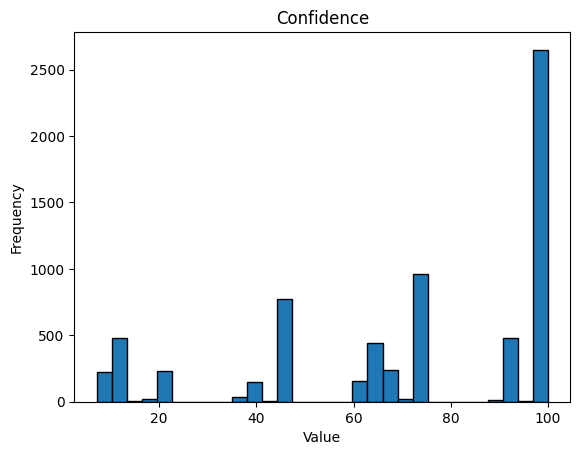

In [ ]:
df_matched['confidence'].hist(bins=30, edgecolor='black', grid=False)

plt.title('Confidence')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
confidence_conditions = [df_matched['confidence'] < 25, 
                        df_matched['confidence'] < 50,
                        df_matched['confidence'] < 75,
                        df_matched['confidence'] < 100]
confidence_results = ['low', 'low-medium', 'medium', 'high']

df_matched['confidence_label'] = np.select(confidence_conditions, confidence_results, default='perfect')

In [ ]:
display(df_matched.head())

,md_player_name,md_player_id,md_draft_class,md_position,fuzz_college,matched_name,matched_draft_year,matched_college,matched_position,nflread_pfr_id,confidence,confidence_label
0,a'shawn robinson,ashawnrobinson2016,2016,dt,alabama,a'shawn robinson,2016.0,alabama,dt,RobiAS00,100.0000,perfect
1,a.c. leonard,acleonard2014,2014,te,tennessee state,matt leonard,NaN,stanford,dt,LeonMa20,9.9975,low
2,a.j. brown,ajbrown2019,2019,wr,ole miss,a.j. brown,2019.0,mississippi,wr,BrowAJ00,93.3300,high
3,a.j. cann,ajcann2015,2015,g,south carolina,a.j. cann,2015.0,south carolina,g,CannA.00,100.0000,perfect
4,a.j. derby,ajderby2015,2015,te,arkansas,a.j. derby,2015.0,arkansas; coffeyville cc; iowa,te,DerbA.00,93.3300,high


We only use records that have a high confidence. This dramatically drops our sample size, but our data is still much bigger than data used in other studies

In [ ]:
df_matched_filter = df_matched[(df_matched['confidence_label'] == 'high') | (df_matched['confidence_label'] == 'perfect')]
df_matched_filter = df_matched_filter[['md_player_name', 'md_position', 'md_draft_class', 'nflread_pfr_id', 'md_player_id']] # Remove extra columns
# df_final_player_records  = 

In [ ]:
display(df_matched_filter.head())

,md_player_name,md_position,md_draft_class,nflread_pfr_id,md_player_id
0,a'shawn robinson,dt,2016,RobiAS00,ashawnrobinson2016
2,a.j. brown,wr,2019,BrowAJ00,ajbrown2019
3,a.j. cann,g,2015,CannA.00,ajcann2015
4,a.j. derby,te,2015,DerbA.00,ajderby2015
8,a.j. green,wr,2011,GreeA.00,ajgreen2011


## Merge combine + anthro stats with player matches + height/weight/positions

In [ ]:
# Merge from players that matched

df_nfl_combine_stats = pd.merge(df_nfl_combine, df_matched_filter, how = 'inner', left_on = ['md_player_id'], right_on = ['md_player_id'])
nfl_combine_columns_to_drop  = [
    'md_player_name_x',
    'md_player_id',
    'md_draft_class_x',
    'md_position_x',
    'md_draft_class_y',
    'md_college',
    'md_url',
    'md_position_y'
]
df_nfl_combine_stats = df_nfl_combine_stats.drop(columns=nfl_combine_columns_to_drop)

nfl_combine_columns_to_rename = {
    'md_player_name_y':'player_name',
    'nflread_pfr_id': 'pfr_id'
}


df_nfl_combine_stats = df_nfl_combine_stats.rename(columns=nfl_combine_columns_to_rename)
df_nfl_combine_stats = df_nfl_combine_stats[['player_name','pfr_id', 'md_weight_lbs','md_height_in','md_arm_length_in', 'md_wing_span_in', 'md_hand_size_in','md_yard_40_dash_sec', 'md_yard_60_shuttle_sec',
                                             'md_yard_10_split_sec','md_yard_20_split_sec', 'md_cone_drill_sec','md_yard_20_shuttle_sec','md_vert_jump_in','md_broad_jump_in','md_bench_press_reps']]

# Merge to fill in height + get player_positions

df_nfl_combine_stats = pd.merge(df_nfl_combine_stats, players[['pfr_id', 'position', 'position_group', 'def_pos_flag', 'off_pos_flag', 'height', 'weight']], how = 'inner', left_on='pfr_id', right_on='pfr_id', suffixes=['','']) # 
df_nfl_combine_stats['md_weight_lbs'] = df_nfl_combine_stats['md_weight_lbs'].fillna(df_nfl_combine_stats['weight'])
df_nfl_combine_stats['md_height_in'] = df_nfl_combine_stats['md_height_in'].fillna(df_nfl_combine_stats['height'])
df_nfl_combine_stats = df_nfl_combine_stats.drop(columns=['height', 'weight'])



# Flags for missing anthro features - height and weight are key
df_nfl_combine_stats['missing_weight'] = np.where(df_nfl_combine_stats['md_weight_lbs'].isna(),1,0)
df_nfl_combine_stats['missing_height'] = np.where(df_nfl_combine_stats['md_height_in'].isna(),1,0)
df_nfl_combine_stats['missing_arm_length'] = np.where(df_nfl_combine_stats['md_arm_length_in'].isna(),1,0)
df_nfl_combine_stats['missing_wing_span'] = np.where(df_nfl_combine_stats['md_wing_span_in'].isna(),1,0)
df_nfl_combine_stats['missing_hand_size'] = np.where(df_nfl_combine_stats['md_hand_size_in'].isna(),1,0)
# df_nfl_combine_stats.rename

display(df_nfl_combine_stats.head())
display(df_nfl_combine_stats.columns)


,player_name,pfr_id,md_weight_lbs,md_height_in,md_arm_length_in,md_wing_span_in,md_hand_size_in,md_yard_40_dash_sec,md_yard_60_shuttle_sec,md_yard_10_split_sec,...,md_bench_press_reps,position,position_group,def_pos_flag,off_pos_flag,missing_weight,missing_height,missing_arm_length,missing_wing_span,missing_hand_size
0,a'shawn robinson,RobiAS00,307.0,72.0,34.500,NaN,10.50,5.20,NaN,1.78,...,22.0,dt,DL,1,0,0,0,0,1,0
1,a.j. brown,BrowAJ00,226.0,72.0,32.875,78.0,9.75,4.49,NaN,NaN,...,19.0,wr,WR,0,1,0,0,0,0,0
2,a.j. cann,CannA.00,313.0,72.0,32.625,NaN,10.25,NaN,NaN,NaN,...,26.0,g,OL,0,1,0,0,0,1,0
3,a.j. derby,DerbA.00,255.0,72.0,30.500,NaN,9.50,NaN,NaN,NaN,...,15.0,te,TE,0,1,0,0,0,1,0
4,a.j. green,GreeA.00,211.0,72.0,34.375,NaN,9.25,4.48,11.46,1.55,...,18.0,wr,WR,0,1,0,0,0,1,0


Index(['player_name', 'pfr_id', 'md_weight_lbs', 'md_height_in',
       'md_arm_length_in', 'md_wing_span_in', 'md_hand_size_in',
       'md_yard_40_dash_sec', 'md_yard_60_shuttle_sec', 'md_yard_10_split_sec',
       'md_yard_20_split_sec', 'md_cone_drill_sec', 'md_yard_20_shuttle_sec',
       'md_vert_jump_in', 'md_broad_jump_in', 'md_bench_press_reps',
       'position', 'position_group', 'def_pos_flag', 'off_pos_flag',
       'missing_weight', 'missing_height', 'missing_arm_length',
       'missing_wing_span', 'missing_hand_size'],
      dtype='object')

## Save NFL anthro features/combine

In [ ]:
df_nfl_combine_stats.to_csv(data_folder / 'nfl_combine_stats_pfr_id.csv', index=False)

# Get player/team weekly and season stats

In [ ]:
# Initialize df to hold combine + player_stats


df_player_key_1 = df_nfl_combine_stats[['pfr_id']].copy()
df_player_key_1 = pd.merge(df_player_key_1, players, how = 'inner', left_on = 'pfr_id', right_on = 'pfr_id', suffixes=['','_y'])

df_player_key = df_player_key_1[['pfr_id','gsis_id','position', 'position_group', 'def_pos_flag', 'off_pos_flag', 'draft_round', 'draft_pick']]
df_player_key.to_csv(data_folder/'player_id_key.csv',index=False) # Get a CSV of player_ids

player_keys_lookup = set(df_player_key['gsis_id']) # Get set of player gsis ids
# ['player_name','pfr_id','position']

In [ ]:
display(df_player_key_1.head())

,pfr_id,gsis_id,display_name,common_first_name,first_name,last_name,short_name,football_name,suffix,esb_id,...,years_of_experience,pff_position,pff_status,draft_year,draft_round,draft_pick,draft_team,def_pos_flag,off_pos_flag,np_name
0,RobiAS00,00-0032889,a'shawn robinson,A'Shawn,A'Shawn,Robinson,A.Robinson,A'Shawn,None,ROB367960,...,11,DI,A,2016.0,2.0,46.0,DET,1,0,a'shawn robinson
1,BrowAJ00,00-0035676,a.j. brown,A.J.,Arthur,Brown,A.Brown,A.J.,None,BRO413223,...,8,WR,A,2019.0,2.0,51.0,TEN,0,1,a.j. brown
2,CannA.00,00-0032255,a.j. cann,A.J.,Aaron,Cann,A.Cann,A.J.,None,CAN364949,...,8,G,A,2015.0,3.0,67.0,JAX,0,1,a.j. cann
3,DerbA.00,00-0031609,a.j. derby,A.J.,Alexander,Derby,A.Derby,A.J.,None,DER139014,...,4,TE,None,2015.0,6.0,202.0,NE,0,1,a.j. derby
4,GreeA.00,00-0027942,a.j. green,A.J.,Adriel,Green,A.Green,A.J.,None,GRE034604,...,12,WR,A,2011.0,1.0,4.0,CIN,0,1,a.j. green


In [ ]:
df_player_key.head()

,pfr_id,gsis_id,position,position_group,def_pos_flag,off_pos_flag,draft_round,draft_pick
0,RobiAS00,00-0032889,dt,DL,1,0,2.0,46.0
1,BrowAJ00,00-0035676,wr,WR,0,1,2.0,51.0
2,CannA.00,00-0032255,g,OL,0,1,3.0,67.0
3,DerbA.00,00-0031609,te,TE,0,1,6.0,202.0
4,GreeA.00,00-0027942,wr,WR,0,1,1.0,4.0


## Get player_id & positin from df_player_key

In [ ]:
# Use for aggregate position dataframes

position_lookup = (
    df_player_key[['gsis_id', 'position_group']]
    .dropna()
    .assign(gsis_id=lambda x: x['gsis_id'].astype(str).str.strip(),
            position=lambda x: x['position_group'].str.lower().str.strip())
    .set_index('gsis_id')['position']
    .to_dict()
)

qb_positions = ['qb']
rb_positions = ['rb']
wr_positions = ['wr', 'te'] 
def_positions = ['db','lb','dl']


In [ ]:
# set_check = set()
# for id, positon in position_lookup.items():
#     set_check.add(positon)

# print(set_check)

Extract player data from the lowest draft season the highest draft season

In [ ]:
min_draft_season = df['md_draft_class'].min()
max_draft_season = df['md_draft_class'].max()
seasons = [season for season in range(min_draft_season, max_draft_season)]

print(f'Retrieve data from {min_draft_season} to {max_draft_season}')

Retrieve data from 1999 to 2026


## Load PBP Stats

In [ ]:
def get_pbp(seasons):
    
    '''
    Load the pbp stats by seasona and returne a full dataframe. 
    Use this to get the normalize stats for off/defen
    '''
    print(f'--- PBP STATS ---')
    frames = []
    
    for season in seasons:
        try:
            df = nfl.load_pbp([season]).to_pandas()
            print(f'\tLoading {season}')
            frames.append(df)
            time.sleep(5)
        except ConnectionError as e:
            print(f"\tSkipping {season}: {e}")

    return pd.concat(frames, ignore_index=True)

In [ ]:
# df_pbp_1 = get_pbp(seasons)
# df_pbp_1.to_csv('df_pbp.csv', index=False)

In [ ]:
df_pbp_1 = pd.read_csv('df_pbp.csv')

C:\Users\habib\AppData\Local\Temp\ipykernel_58804\2518170681.py:1: DtypeWarning: Columns (36,37,45,179,180,182,183,189,190,193,194,197,198,203,204,205,206,207,208,209,210,211,212,213,214,218,219,220,222,224,226,233,234,235,236,237,238,243,244,245,248,249,253,254,255,260,262,263,266,267,268,269,283,284,292,293,294,295,296,299,301,302,303,306,332) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pbp_1 = pd.read_csv('df_pbp.csv')


In [ ]:
# REG season only
df_pbp = df_pbp_1.copy()
df_pbp = df_pbp[df_pbp['season_type'] == 'REG']

In [ ]:
# # Quick check
# print(df_pbp[df_pbp['game_id'] == '2000_01_CHI_MIN'].to_string())

In [ ]:
off_cols = [
    'passer_player_id',
    'rusher_player_id',
    'receiver_player_id'
]

def_cols = [
    'solo_tackle_1_player_id',
    'interception_player_id',
    'sack_player_id',
    'tackle_for_loss_1_player_id',
    'pass_defense_1_player_id',
    'tackle_with_assist_1_player_id'
]

relevant_cols = off_cols + def_cols

In [ ]:
def add_lag_features(df, player_col, epa_col):
    '''
    Get lag features
    '''
    df = df.sort_values([player_col, 'season'])

    # Prior year EPA
    df[f'{epa_col}_prior'] = df.groupby(player_col)[epa_col].shift(1)

    # Rookie flag
    if 'rookie_flag' not in df.columns:
        df['rookie_flag'] = np.where(df[f'{epa_col}_prior'].isna(), 1, 0)

    return df

In [ ]:
def add_experience(df, player_col):
    df = df.sort_values([player_col, 'season'])
    
    df['years_experience'] = (
        df.groupby(player_col).cumcount() + 1
    )
    
    return df

In [ ]:
qb = df_pbp[df_pbp['qb_dropback'] == 1].copy()
qb = qb[qb['passer_player_id'].map(position_lookup).isin(qb_positions)]

qb_agg = (qb.groupby(['passer_player_id', 'season'])
    .agg(
        passing_epa=('epa', 'sum'),
        qb_epa=('qb_epa', 'sum'),
        dropbacks=('qb_dropback', 'sum')
    ).reset_index()
)

qb_agg['epa_per_dropback'] = qb_agg['passing_epa'] / qb_agg['dropbacks'] # tean impact
qb_agg['qb_epa_per_dropback'] = qb_agg['qb_epa'] / qb_agg['dropbacks'] # QB only performance - QB leaning EPA

qb_agg = add_lag_features(qb_agg, 'passer_player_id', 'epa_per_dropback')
qb_agg = add_lag_features(qb_agg, 'passer_player_id', 'qb_epa_per_dropback')
qb_agg = add_experience(qb_agg, 'passer_player_id')
# Get static features 
qb_agg = pd.merge(qb_agg, df_player_key[['gsis_id','draft_round', 'draft_pick']], how='left', left_on='passer_player_id', right_on='gsis_id').drop(columns=['gsis_id'])

# No small sample sizes
qb_agg = qb_agg[qb_agg['dropbacks'] >= 20]
print(qb_agg.shape)
qb_agg.head()

# 
print(f'Number of QB IDs in data {qb_agg["passer_player_id"].nunique()}')

(1095, 13)
Number of QB IDs in data 205


In [ ]:
qb_agg.head()

,passer_player_id,season,passing_epa,qb_epa,dropbacks,epa_per_dropback,qb_epa_per_dropback,epa_per_dropback_prior,rookie_flag,qb_epa_per_dropback_prior,years_experience,draft_round,draft_pick
1,00-0001823,2000,22.211612,22.211612,208.0,0.106787,0.106787,NaN,1,NaN,1,4.0,131.0
2,00-0001823,2001,-13.617455,10.685959,610.0,-0.022324,0.017518,0.106787,0,0.106787,2,4.0,131.0
3,00-0001823,2002,-8.407617,9.373769,568.0,-0.014802,0.016503,-0.022324,0,0.017518,3,4.0,131.0
4,00-0001823,2003,12.784772,19.540968,551.0,0.023203,0.035465,-0.014802,0,0.016503,4,4.0,131.0
5,00-0001823,2004,12.240025,19.958825,586.0,0.020887,0.034059,0.023203,0,0.035465,5,4.0,131.0


In [ ]:
rb = df_pbp[df_pbp['rush_attempt'] == 1].copy()
rb = rb[rb['rusher_player_id'].map(position_lookup).isin(rb_positions)]

rb_agg = (rb.groupby(['rusher_player_id', 'season']).agg(
          rushing_epa=('epa', 'sum'),
          rush_attempts=('rush_attempt', 'sum')).reset_index())

rb_agg['epa_per_rush'] = (rb_agg['rushing_epa'] / rb_agg['rush_attempts'].replace(0, np.nan))
rb_agg = add_lag_features(rb_agg, 'rusher_player_id', 'epa_per_rush')
rb_agg = add_experience(rb_agg, 'rusher_player_id')

# Get static features 
rb_agg = pd.merge(rb_agg, df_player_key[['gsis_id','draft_round', 'draft_pick']], how='left', left_on='rusher_player_id', right_on='gsis_id').drop(columns=['gsis_id'])
# No small sample sizes
rb_agg = rb_agg[rb_agg['rush_attempts'] >= 20]

print(rb_agg.shape)
print(f'Number of RB IDs in data {rb_agg["rusher_player_id"].nunique()}')

(1464, 10)
Number of RB IDs in data 359


In [ ]:
rb_agg.head()

,rusher_player_id,season,rushing_epa,rush_attempts,epa_per_rush,epa_per_rush_prior,rookie_flag,years_experience,draft_round,draft_pick
0,00-0003136,1999,-2.159327,35.0,-0.061695,NaN,1,1,2.0,54.0
1,00-0003136,2000,-4.392262,22.0,-0.199648,-0.061695,0,2,2.0,54.0
3,00-0003136,2002,-10.310707,49.0,-0.210423,0.567892,0,4,2.0,54.0
4,00-0003136,2003,2.838742,27.0,0.105139,-0.210423,0,5,2.0,54.0
5,00-0003136,2004,6.060002,21.0,0.288572,0.105139,0,6,2.0,54.0


In [ ]:
wr = df_pbp[df_pbp['pass_attempt'] == 1].copy()
wr = wr[wr['receiver_player_id'].map(position_lookup).isin(wr_positions)]
wr = wr[wr['receiver_player_id'].notna()] # Only plays where the wr actually gets the balls

wr_agg = (wr.groupby(['receiver_player_id', 'season']).agg(
          receiving_epa=('epa', 'sum'),
          targets=('receiver_player_id', 'count')).reset_index())

wr_agg['epa_per_target'] = (wr_agg['receiving_epa'] / wr_agg['targets'].replace(0, np.nan))
wr_agg = add_lag_features(wr_agg, 'receiver_player_id', 'epa_per_target')
wr_agg = add_experience(wr_agg, 'receiver_player_id')

# Get static features 
wr_agg = pd.merge(wr_agg, df_player_key[['gsis_id','draft_round', 'draft_pick']], how='left', left_on='receiver_player_id', right_on='gsis_id').drop(columns=['gsis_id'])
# No small sample sizes
wr_agg = wr_agg[wr_agg['targets'] >= 20]
print(wr_agg.shape)
print(f'Number of WR IDs in data {wr_agg["receiver_player_id"].nunique()}')

(2915, 10)
Number of WR IDs in data 676


In [ ]:
wr_agg.head()

,receiver_player_id,season,receiving_epa,targets,epa_per_target,epa_per_target_prior,rookie_flag,years_experience,draft_round,draft_pick
6,00-0000869,2002,43.653773,80,0.545672,0.564721,0,4,3.0,71.0
8,00-0001532,1999,1.172459,81,0.014475,NaN,1,1,1.0,8.0
9,00-0001532,2000,39.973408,135,0.296099,0.014475,0,2,1.0,8.0
10,00-0001532,2001,65.695819,175,0.375405,0.296099,0,3,1.0,8.0
11,00-0001532,2002,6.162738,75,0.082170,0.375405,0,4,1.0,8.0


In [ ]:
# Keep first person on the same for defense

def_df = df_pbp[
    df_pbp['solo_tackle_1_player_id'].notna() |
    df_pbp['sack_player_id'].notna() |
    df_pbp['interception_player_id'].notna() |
    df_pbp['pass_defense_1_player_id'].notna()
].copy()

# Assign defender
def_df['defender_id'] = (
    def_df['solo_tackle_1_player_id']
    .fillna(def_df['sack_player_id'])
    .fillna(def_df['interception_player_id'])
    .fillna(def_df['pass_defense_1_player_id'])
)

def_df = def_df[def_df['defender_id'].map(position_lookup).isin(def_positions)]
# Flip EPA
def_df['def_epa'] = -def_df['epa']

def_agg = (def_df.groupby(['defender_id', 'season']).agg(
              total_def_epa=('def_epa', 'sum'),
              plays=('def_epa', 'count')).reset_index())

def_agg['def_epa_per_play'] = (def_agg['total_def_epa'] / def_agg['plays'].replace(0, np.nan)) 
def_agg = add_lag_features(def_agg, 'defender_id', 'def_epa_per_play')
def_agg = add_experience(def_agg, 'defender_id')

# Get static features 
def_agg = pd.merge(def_agg, df_player_key[['gsis_id','draft_round', 'draft_pick']], how='left', left_on='defender_id', right_on='gsis_id').drop(columns=['gsis_id'])
# No small sample sizes
def_agg = def_agg[def_agg['plays'] >= 20]
print(def_agg.shape)
print(f'Number of Def IDs in data {def_agg["defender_id"].nunique()}')
def_agg.head()

(2203, 10)
Number of Def IDs in data 516


,defender_id,season,total_def_epa,plays,def_epa_per_play,def_epa_per_play_prior,rookie_flag,years_experience,draft_round,draft_pick
0,00-0000008,1999,-1.175081,47,-0.025002,NaN,1,1,2.0,45.0
2,00-0000585,1999,-43.903432,76,-0.577677,NaN,1,1,1.0,7.0
3,00-0000585,2000,-19.784305,63,-0.314037,-0.577677,0,2,1.0,7.0
4,00-0000585,2001,-10.886193,61,-0.178462,-0.314037,0,3,1.0,7.0
5,00-0000585,2002,-22.471871,75,-0.299625,-0.178462,0,4,1.0,7.0


In [ ]:
qb_agg.to_csv(data_folder/'qb_model_data.csv', index=False)
wr_agg.to_csv(data_folder/'wr_model_data.csv', index=False)
def_agg.to_csv(data_folder/'def_model_data.csv', index=False)
rb_agg.to_csv(data_folder/'rb_model_data.csv', index=False)

### Roster Stats

In [ ]:

# Pass offense
pass_off = df_pbp[df_pbp['qb_dropback'] == 1].groupby(['posteam', 'season']).agg(
    pass_epa=('epa', 'sum'),
    dropbacks=('qb_dropback', 'sum')).reset_index() # 

# Rush offense  
rush_off = df_pbp[df_pbp['rush_attempt'] == 1].groupby(['posteam', 'season']).agg(
    rush_epa=('epa', 'sum'),
    rush_attempts=('rush_attempt', 'sum')).reset_index()

# Combine
team_off = pd.merge(pass_off, rush_off, on=['posteam', 'season'], how='outer')
team_off['total_off_plays'] = team_off['dropbacks'] + team_off['rush_attempts']
team_off['off_epa_per_play'] = (team_off['pass_epa'] + team_off['rush_epa']) / team_off['total_off_plays']


# Defense

pass_def = df_pbp[df_pbp['qb_dropback'] == 1].groupby(['defteam', 'season']).agg(
    pass_epa_allowed=('epa', 'sum'),
    dropbacks_faced=('qb_dropback', 'sum')).reset_index()

rush_def = df_pbp[df_pbp['rush_attempt'] == 1].groupby(['defteam', 'season']).agg(
    rush_epa_allowed=('epa', 'sum'),
    rush_attempts_faced=('rush_attempt', 'sum')
).reset_index()

team_def = pd.merge(pass_def, rush_def, on=['defteam', 'season'], how='outer')
team_def['total_def_plays'] = team_def['dropbacks_faced'] + team_def['rush_attempts_faced']
team_def['def_epa_per_play'] = (team_def['pass_epa_allowed'] + team_def['rush_epa_allowed']) / team_def['total_def_plays']

# Merge
team_epa = pd.merge(
    team_off.rename(columns={'posteam': 'team'}),
    team_def.rename(columns={'defteam': 'team'}),
    on=['team', 'season'],
    how='inner'
)

# Team epa
print(team_epa.shape)
team_epa.head()

(861, 14)


,team,season,pass_epa,dropbacks,rush_epa,rush_attempts,total_off_plays,off_epa_per_play,pass_epa_allowed,dropbacks_faced,rush_epa_allowed,rush_attempts_faced,total_def_plays,def_epa_per_play
0,ARI,1999,-117.134066,604.0,-72.284747,396.0,1000.0,-0.189419,-7.948122,532.0,-5.724189,542.0,1074.0,-0.012730
1,ARI,2000,-69.705888,597.0,-70.759920,346.0,943.0,-0.148956,85.919755,487.0,32.539719,579.0,1066.0,0.111125
2,ARI,2001,31.898784,571.0,-63.029843,401.0,972.0,-0.032028,49.782970,591.0,-22.647174,497.0,1088.0,0.024941
3,ARI,2002,-65.066372,613.0,-33.078936,414.0,1027.0,-0.095565,87.396306,563.0,-8.978611,490.0,1053.0,0.074471
4,ARI,2003,-107.509242,576.0,-68.255202,406.0,982.0,-0.178986,94.578229,517.0,-27.386826,476.0,993.0,0.067665


In [ ]:
# Add QB epa to team epa

qb_team = df_pbp[df_pbp['qb_dropback'] == 1][
    ['passer_player_id', 'posteam', 'season']
].dropna()

# Merge QB EPA
qb_team = pd.merge(
    qb_team,
    qb_agg,
    left_on=['passer_player_id', 'season'],
    right_on=['passer_player_id', 'season'],
    how='left'
)

# Aggregate to team level (average QB performance)
qb_team_agg = qb_team.groupby(['posteam', 'season']).agg(
    team_qb_epa=('epa_per_dropback', 'mean')
).reset_index().rename(columns={'posteam': 'team'})

team_epa = pd.merge(
    team_epa,
    qb_team_agg,
    on=['team', 'season'],
    how='left'
)

# Add lagg features
team_epa = team_epa.sort_values(['team', 'season'])

team_epa['off_epa_prior'] = team_epa.groupby('team')['off_epa_per_play'].shift(1)
team_epa['def_epa_prior'] = team_epa.groupby('team')['def_epa_per_play'].shift(1)

# Add flag for QB rookie season
team_epa['first_season_flag'] = np.where(team_epa['off_epa_prior'].isna(), 1, 0)

In [ ]:
# # Get roster data 
# roster_frames = []
# for season in seasons:
#     try:
#         print(f'Loading {season}')
#         season_rosters = nfl.load_rosters(season)
#         time.sleep(5)
#     except ConnectionError as e:
#         print(f'Failed to load {season}')
#         continue
#     roster_frames.append(season_rosters.to_pandas())

# df_roster = pd.concat(roster_frames, ignore_index=True)
# df_roster.to_csv('df_roster.csv', index=False)

In [ ]:
df_roster = pd.read_csv('df_roster.csv')

C:\Users\habib\AppData\Local\Temp\ipykernel_58804\1028169384.py:1: DtypeWarning: Columns (3,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_roster = pd.read_csv('df_roster.csv')


In [ ]:
df_roster_agg = df_roster.groupby(['team', 'season']).agg(
    avg_height =('height', 'mean'),
    avg_weight =('weight', 'mean')
).reset_index()

In [ ]:
df_roster_agg.head()

,team,season,avg_height,avg_weight
0,ARI,1999,74.671875,254.859375
1,ARI,2000,74.323944,251.197183
2,ARI,2001,74.153846,247.046154
3,ARI,2016,74.245098,243.166667
4,ARI,2017,74.173077,239.846154


In [ ]:
# Final Team Data

df_roster_final = pd.merge(
    df_roster_agg, 
    team_epa,
    on=['team', 'season'],
    how='inner'
)
df_roster_final = df_roster_final.rename(columns={
    'avg_height': 'team_avg_height',
    'avg_weight': 'team_avg_weight'
})

print(df_roster_final.shape)
print(df_roster_final[['team_avg_height', 'team_avg_weight']].describe())
# print(df_roster_final.duplicated(['team', 'season']).sum()) # No dupes
display(df_roster_final.head())


(749, 20)
       team_avg_height  team_avg_weight
count       749.000000       749.000000
mean         73.950779       244.378948
std           0.309448         3.626166
min          72.920000       234.326733
25%          73.747573       241.941748
50%          73.969231       244.350877
75%          74.171875       246.719298
max          74.802083       257.061538


,team,season,team_avg_height,team_avg_weight,pass_epa,dropbacks,rush_epa,rush_attempts,total_off_plays,off_epa_per_play,pass_epa_allowed,dropbacks_faced,rush_epa_allowed,rush_attempts_faced,total_def_plays,def_epa_per_play,team_qb_epa,off_epa_prior,def_epa_prior,first_season_flag
0,ARI,1999,74.671875,254.859375,-117.134066,604.0,-72.284747,396.0,1000.0,-0.189419,-7.948122,532.0,-5.724189,542.0,1074.0,-0.012730,NaN,NaN,NaN,1
1,ARI,2000,74.323944,251.197183,-69.705888,597.0,-70.759920,346.0,943.0,-0.148956,85.919755,487.0,32.539719,579.0,1066.0,0.111125,NaN,-0.189419,-0.012730,0
2,ARI,2001,74.153846,247.046154,31.898784,571.0,-63.029843,401.0,972.0,-0.032028,49.782970,591.0,-22.647174,497.0,1088.0,0.024941,NaN,-0.148956,0.111125,0
3,ARI,2016,74.245098,243.166667,9.804531,692.0,-33.140294,399.0,1091.0,-0.021389,-33.947566,621.0,-63.719302,424.0,1045.0,-0.093461,0.010240,0.101693,-0.095615,0
4,ARI,2017,74.173077,239.846154,-92.926690,667.0,-81.773024,409.0,1076.0,-0.162360,-41.919207,623.0,-63.937718,409.0,1032.0,-0.102575,-0.143737,-0.021389,-0.093461,0


In [ ]:
df_roster_final.to_csv(data_folder/'roster_model_data.csv', index=False)